In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("clean/telco_customer_churn_clean.csv")

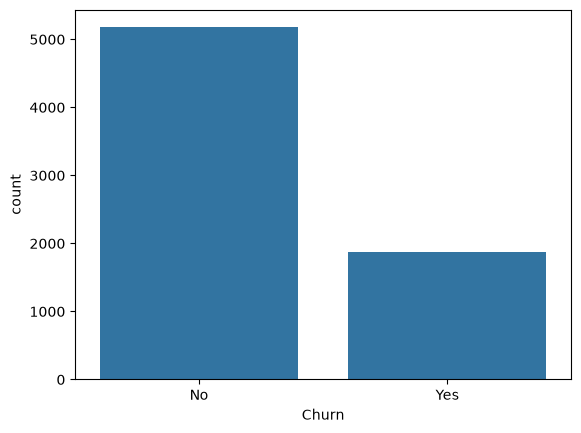

In [2]:
# Valuto gli abbandoni rispetto ai non abbandoni

counts = df["Churn"].value_counts().reset_index()
counts.columns = ["Churn", "count"]

sns.barplot(data=counts, x="Churn", y="count")
plt.show()

<Axes: xlabel='gender'>

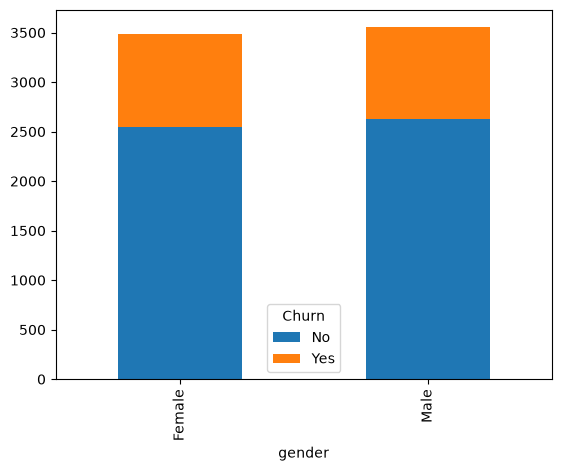

In [3]:
# Valuto il tasso di abbandono degli uomini rispetto a quello delle donne
table = pd.crosstab(df["gender"], df["Churn"])
table.plot(kind="bar", stacked=True)

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

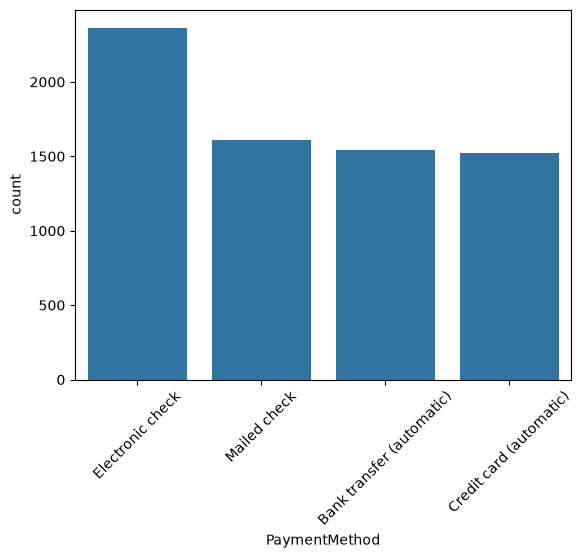

In [4]:
# Sul genere sembra non esserci alcuna differenza di tasso di abbandono.
# Valuto il tipo di pagamento, e il tasso di abbandono per ognuno di essi

sns.barplot(df["PaymentMethod"].value_counts())
plt.xticks(rotation=45)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Bank transfer (automatic)'),
  Text(1, 0, 'Credit card (automatic)'),
  Text(2, 0, 'Electronic check'),
  Text(3, 0, 'Mailed check')])

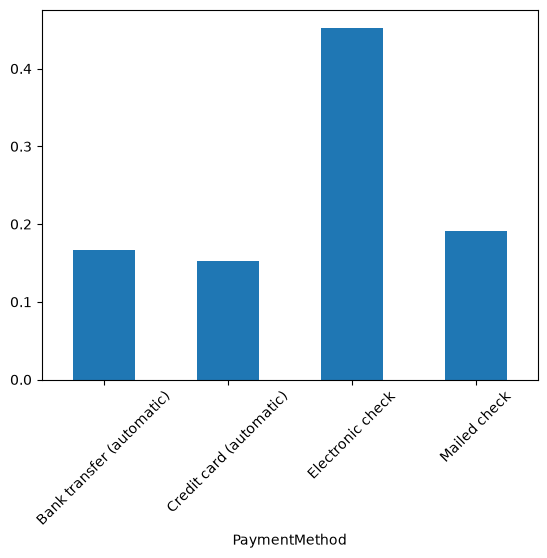

In [5]:
# Ora grafico il tasso di churn per ogni metodo di pagamento

pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")["Yes"].plot(kind="bar")
plt.xticks(rotation=45)

<Axes: xlabel='SeniorCitizen'>

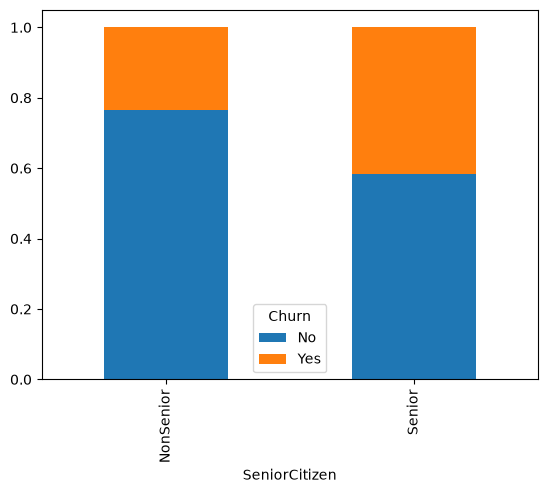

In [6]:
# Valuto il tasso di abbandono (normalizzato) per cittadini senior e non senior
table = pd.crosstab(df["SeniorCitizen"].map({0: "NonSenior", 1:"Senior"}), df["Churn"], normalize="index") 
table.plot(kind="bar", stacked=True)

<Axes: xlabel='Partner'>

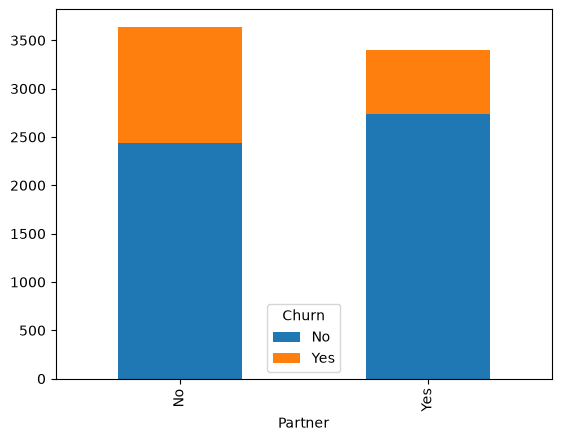

In [7]:
# Valuto il tasso di abbandono (normalizzato) per cittadini con e senza partner
table = pd.crosstab(df["Partner"], df["Churn"])
table.plot(kind="bar", stacked=True)

<Axes: xlabel='Dependents'>

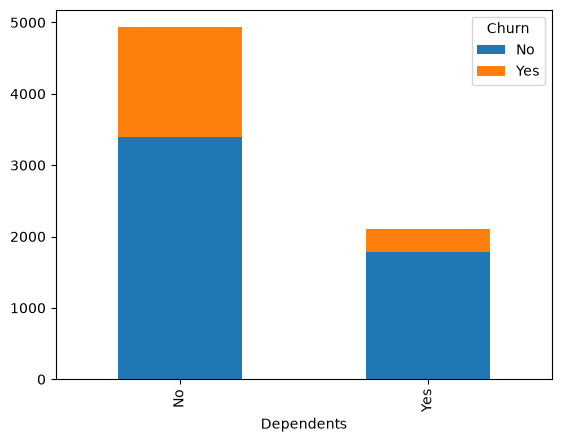

In [8]:
# Valuto il tasso di abbandono (normalizzato) per cittadini con e senza dipendenti
table = pd.crosstab(df["Dependents"], df["Churn"])
table.plot(kind="bar", stacked=True)

tenuremax:  72 tenuremin:  0


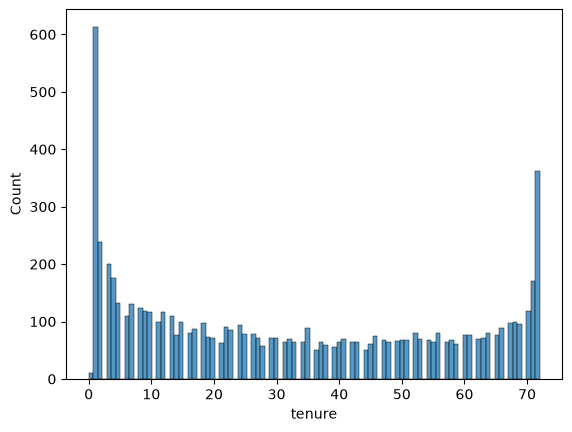

In [9]:
#print(df['tenure'])
#Number of months the customer has stayed with the company
tenuremax = df['tenure'].max()
tenuremin = df['tenure'].min()
print("tenuremax: ", tenuremax ,"tenuremin: ", tenuremin)

#distribuzione della tenure
sns.histplot(df['tenure'],  bins=100)
plt.title='Distribuzione di tenure'


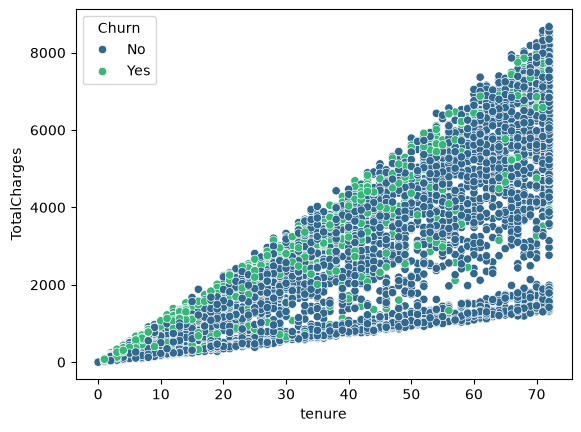

In [10]:
sns.scatterplot(
    data= df,
    x='tenure',
    y='TotalCharges',
    hue='Churn',
    palette='viridis'
)

plt.title = 'Grafico'

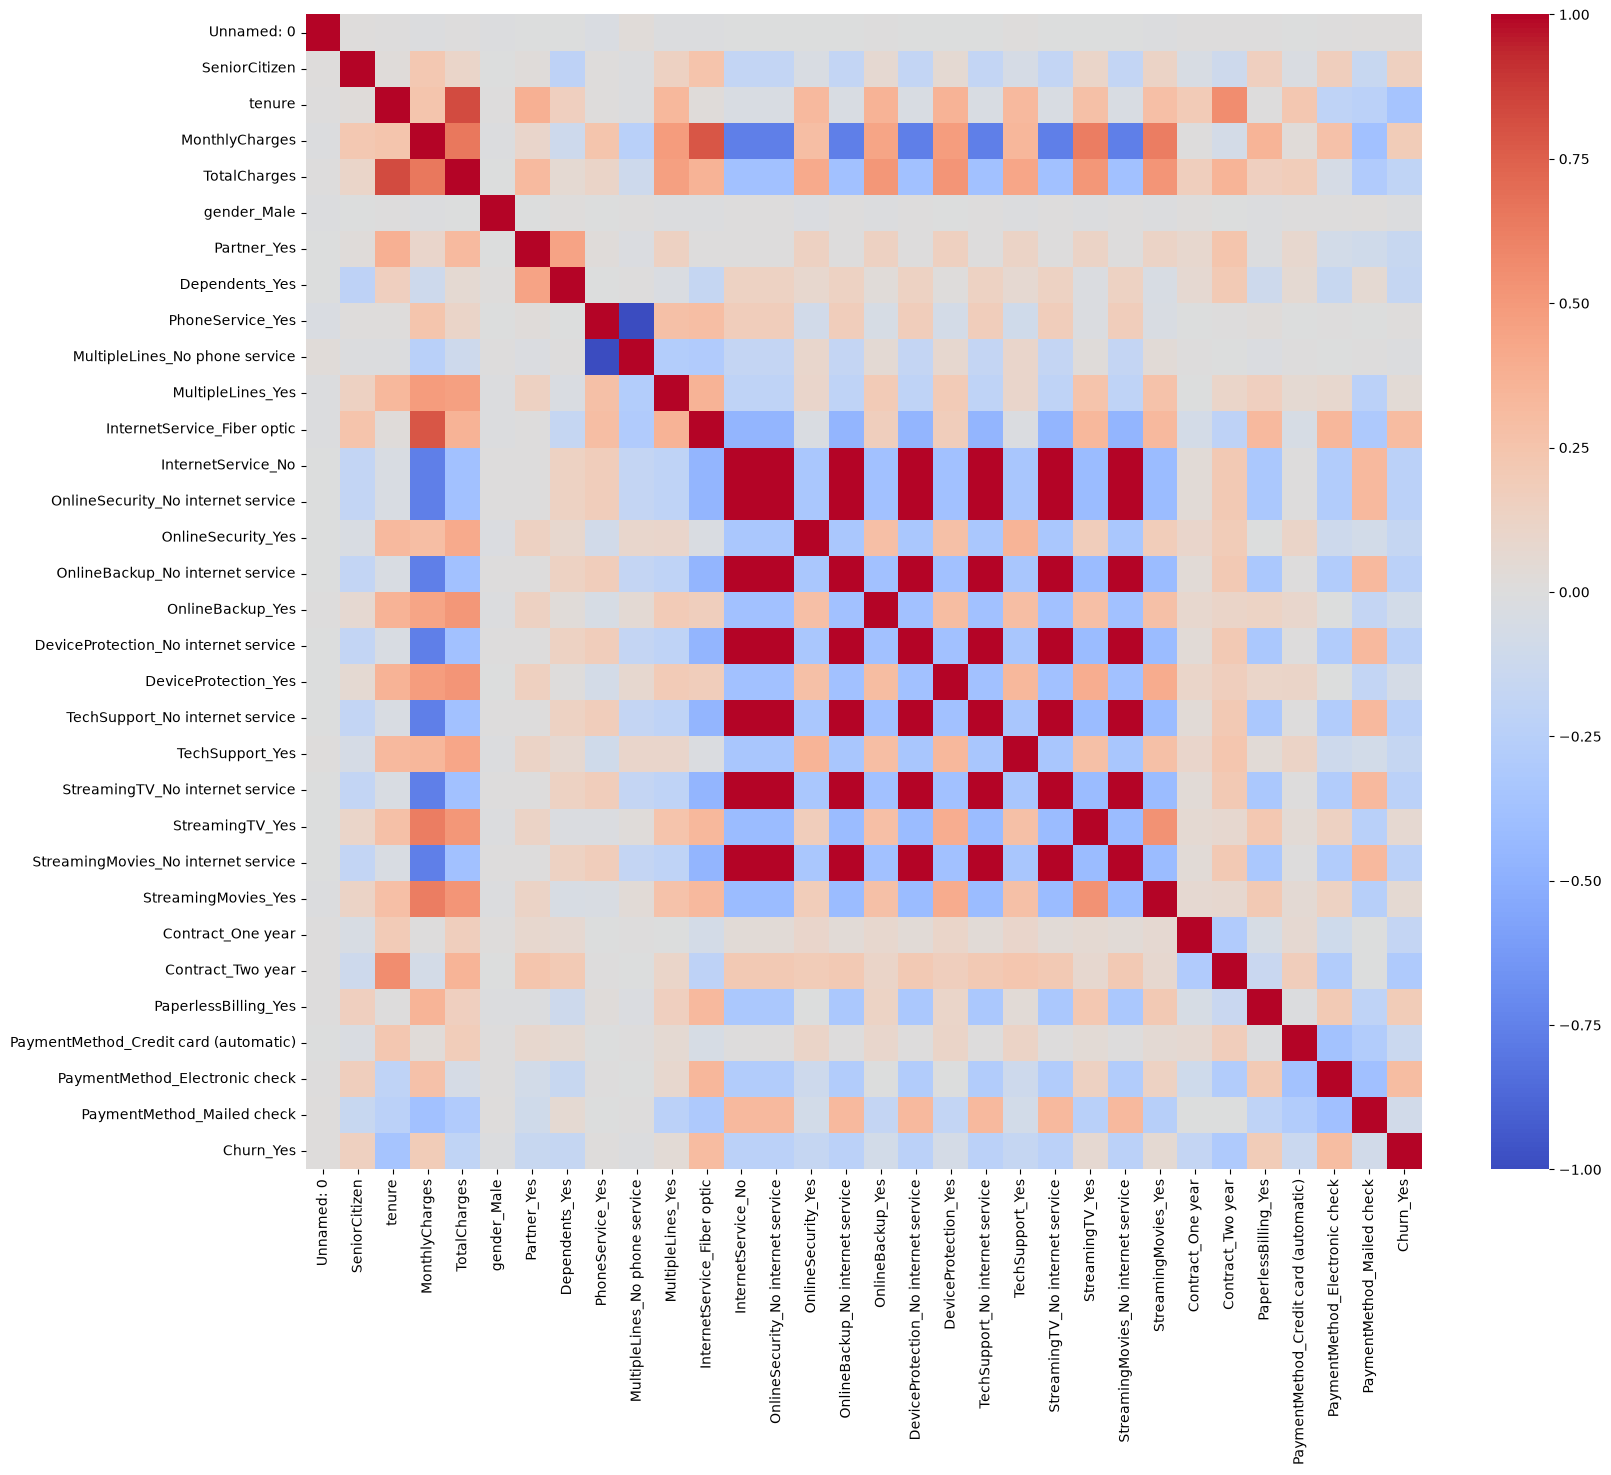

In [11]:
# Calcolo la matrice di correlazione tra le varie colonne, 
# Opto per un'encoding di tipo One-Hot per evitare di falzare il 
# risultato in base all'encoding scelto

df_encoded = pd.get_dummies(df, drop_first=True)

corr = df_encoded.corr()

plt.figure(figsize=(18,15))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title="Matrice Di Correlazione"
plt.show()